In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import os
import datetime
import pandas as pd
import numpy as np
from gnomepy import Strategy, LatencyModel, SchemaBase, Order, OrderExecutionReport
from gnomepy.research.oms import LimitOrderOMS
from gnomepy.research.signals.basic_mm import BasicMMSignal, BasicMMRecorder, RealizedVolatilityModel
from gnomepy.backtest import (
    Backtest,
    MBPSimulatedExchange,
    StaticLatency,
    RiskAverseQueueModel,
    StaticFeeModel
)
from gnomepy.data.types import SchemaType
from gnomepy.data.cached_client import CachedMarketDataClient
from gnomepy.registry.api import RegistryClient
from gnomepy.backtest.recorder import Recorder

# Configuration
START_DATETIME = datetime.datetime(2026, 1, 15, 12, 0)
END_DATETIME = datetime.datetime(2026, 1, 18, 12, 0)
SCHEMA_TYPE = SchemaType.MBP_10
NOTIONAL = 100_000
LISTING_IDS = [1]

# BasicMM parameters
BASIC_MM_PARAMS = {
    'trade_frequency': 1,
    'gamma': 1e14,
    'order_arrival_rate': 7200,
    'volatility_window': 50,
    'volatility_half_life': 0.5,
    'max_inventory': 1.0,
    'max_spread_ticks': None,
    'min_volatility': 1e-5,
    'min_spread_bps': 0.1,
    'vol_threshold_bps': 3.0,
}

# Realized vol model parameters
VOL_MODEL_PARAMS = {
    'window': 100,
    'horizon': 20,
}

STRATEGY_LATENCY = StaticLatency(1_000_000)
NETWORK_LATENCY = StaticLatency(50_000_000)
ORDER_PROCESSING_LATENCY = StaticLatency(20_000_000)

In [26]:
market_data_client = CachedMarketDataClient(
    bucket="gnome-market-data-dev",
    aws_profile_name="AWSAdministratorAccess-443370708724",
)
registry_client = RegistryClient(
    api_key="9WPV7CfeqXa578yVYlxdG3kCPFzACr7YaMU0UVma",
)

In [27]:
listings = []
for listing_id in LISTING_IDS:
    result = registry_client.get_listing(listing_id=listing_id)
    if not result:
        raise ValueError(f"Unable to find listing_id: {listing_id}")
    listings.append(result[0])
    print(f"Loaded: {result[0]}")

listing = listings[0]

Loaded: Listing(listing_id=1, security_id=1, exchange_id=1, exchange_security_id='undefined', exchange_security_symbol='BTC', date_modified='2025-12-23T18:11:06.557Z', date_created='2025-12-23T18:11:06.557Z')


In [28]:
# Create volatility model
vol_model = RealizedVolatilityModel(**VOL_MODEL_PARAMS)

# Create simulated exchange
exchanges = {
    listing.exchange_id: {
        listing.security_id: MBPSimulatedExchange(
            fee_model=StaticFeeModel(taker_fee=0.004, maker_fee=-0.001),
            network_latency=NETWORK_LATENCY,
            order_processing_latency=ORDER_PROCESSING_LATENCY,
            queue_model=RiskAverseQueueModel()
        )
    }
}

# Create signal recorder
signal_recorder = BasicMMRecorder(listing_ids=LISTING_IDS)

# Create signal
basic_mm_signal = BasicMMSignal(
    listing=listing,
    volatility_model=vol_model,
    data_schema_type=SCHEMA_TYPE,
    **BASIC_MM_PARAMS,
    recorder=signal_recorder,
)

# Create OMS
oms = LimitOrderOMS(
    signals=[basic_mm_signal],
    notional=NOTIONAL,
    position_aware_sizing=False,
    position_scaling_factor=0.3
)

In [29]:
class OMSStrategy(Strategy):
    """Generic strategy wrapper for OMS-based strategies."""

    def __init__(self, processing_latency: LatencyModel, oms):
        super().__init__(processing_latency)
        self.oms = oms

    def on_market_data(self, timestamp: int, data: SchemaBase, recorder: Recorder | None = None) -> list[Order]:
        return self.oms.on_market_update(timestamp, data, recorder)

    def on_execution_report(self, timestamp: int, execution_report: OrderExecutionReport, recorder: Recorder | None = None):
        self.oms.on_execution_report(timestamp, execution_report, recorder)

strategy = OMSStrategy(processing_latency=STRATEGY_LATENCY, oms=oms)

In [30]:
backtest = Backtest(
    start_datetime=START_DATETIME,
    end_datetime=END_DATETIME,
    listing_ids=LISTING_IDS,
    schema_type=SCHEMA_TYPE,
    strategy=strategy,
    exchanges=exchanges,
    market_data_client=market_data_client,
    registry_client=registry_client
)

print("Preparing data...")
backtest.prepare_data()

print("Executing backtest...")
backtest.fully_execute()
print("Done.")

Preparing data...
Executing backtest...
Done.


Signal positions: {<gnomepy.research.signals.basic_mm.signal.BasicMMSignal object at 0x3c7372e90>: {1: -0.3549571187911549}}
Overall positions: {1: -0.3549571187911549}
{'total_records': np.int64(861695), 'market_buffer_usage': {1: np.float64(0.538559375)}, 'intent_buffer_usage': {1: np.float64(0.0)}, 'schema_type': 'mbp-10', 'assets': {1: {'market_record_count': 861695, 'market_timestamp_range': (1768509895681343853, 1768682159891429776), 'market_price_range': (94307.5, 95845.5)}}}


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,2657.437731,-2366.189372,0.006964,71.521016,0.734349,2.048738,-1.123088,0.0,0.0


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades,listing_id
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,2657.437731,-2366.189372,0.006964,71.521016,0.734349,2.048738,-1.123088,24.810069,238.0,1


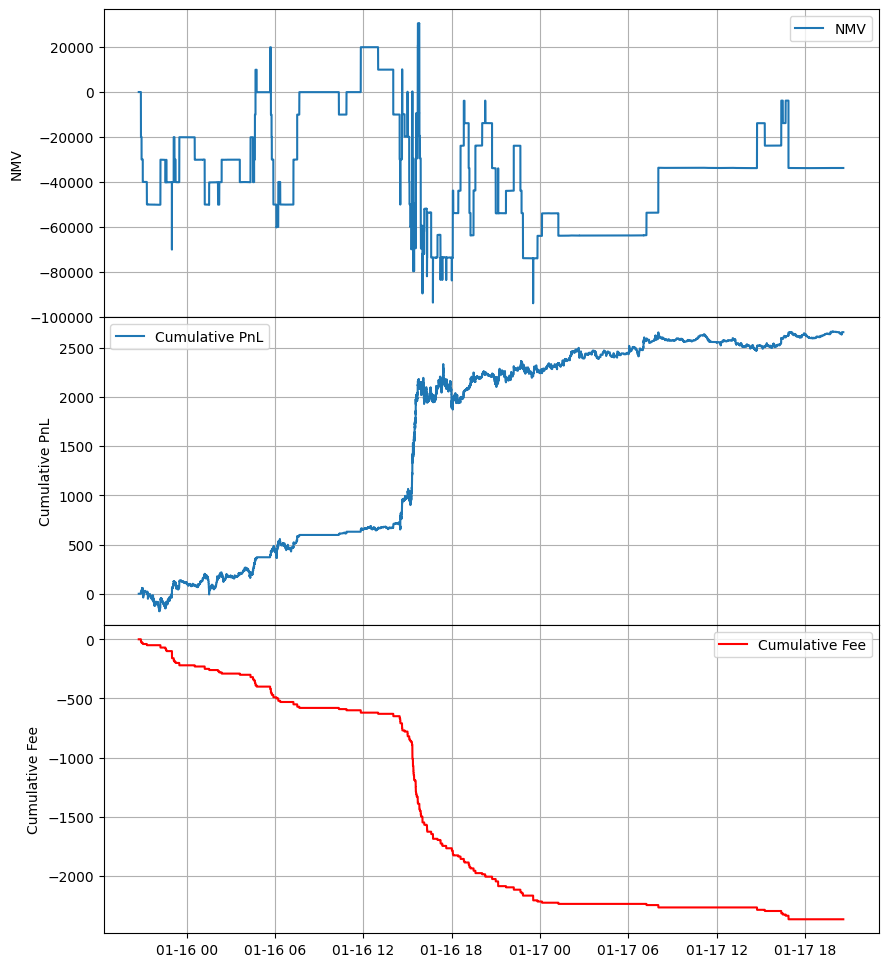

In [31]:
# OMS state
print(f"Signal positions: {oms.signal_positions}")
print(f"Overall positions: {oms.positions}")

from gnomepy.backtest.stats.strategy import StrategyStats

print(backtest.recorder.get_summary_stats())

strat_sts = StrategyStats(
    {
        listing_id: backtest.recorder.get_record(listing_id).stats()
        for listing_id in LISTING_IDS
    },
)

display(strat_sts.summary())
display(strat_sts.listing_summary())
strat_sts.plot()

,mid_price,inventory,realized_vol,predicted_vol_bps,optimal_bid,optimal_ask,reservation_price,best_bid,best_ask,bid_confidence,ask_confidence,circuit_breaker_active,spread
timestamp,,,,,,,,,,,,,
2026-01-15 20:45:08.881774428,95240.5,0.0,0.000011,0.496687,95239.643409,95241.356591,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:09.380811859,95240.5,0.0,0.000011,0.496687,95239.643409,95241.356591,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:09.481040170,95240.5,0.0,0.000011,0.496687,95239.643409,95241.356591,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:09.882042880,95240.5,0.0,0.000011,0.496687,95239.643409,95241.356591,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.282604326,95240.5,0.0,0.000011,0.496687,95239.643409,95241.356591,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.282604326,95240.5,0.0,0.000011,0.496687,95239.643409,95241.356591,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.580799395,95240.5,0.0,0.000011,0.496687,95239.643409,95241.356591,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.880769099,95240.5,0.0,0.000011,0.496687,95239.643409,95241.356591,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.880769099,95240.5,0.0,0.000011,0.496687,95239.643409,95241.356591,95240.5,95240.0,95241.0,0.1,0.1,0,1.0


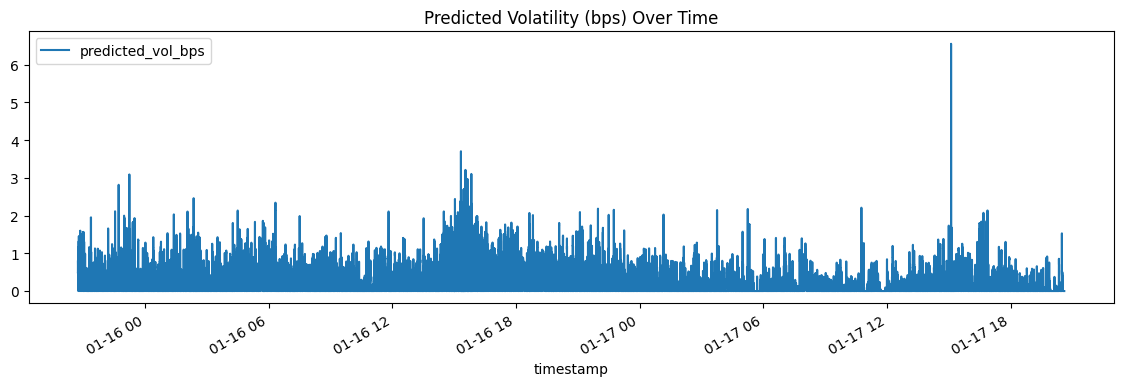

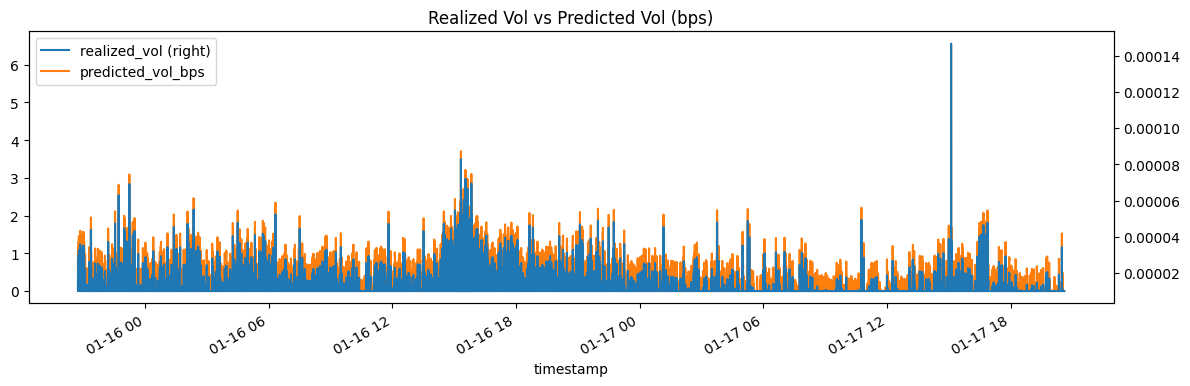

In [32]:
# Model values analysis
if basic_mm_signal.recorder is not None:
    df = basic_mm_signal.recorder.get_record(listing.listing_id).df
    display(df.head(20))

    # Plot predicted volatility over time
    df[['predicted_vol_bps']].plot(title='Predicted Volatility (bps) Over Time', figsize=(14, 4))

    # Plot realized vol vs predicted vol
    df[['realized_vol', 'predicted_vol_bps']].plot(
        title='Realized Vol vs Predicted Vol (bps)',
        secondary_y='realized_vol',
        figsize=(14, 4)
    )

Circuit breaker fired: 451/861356 ticks (0.05%)


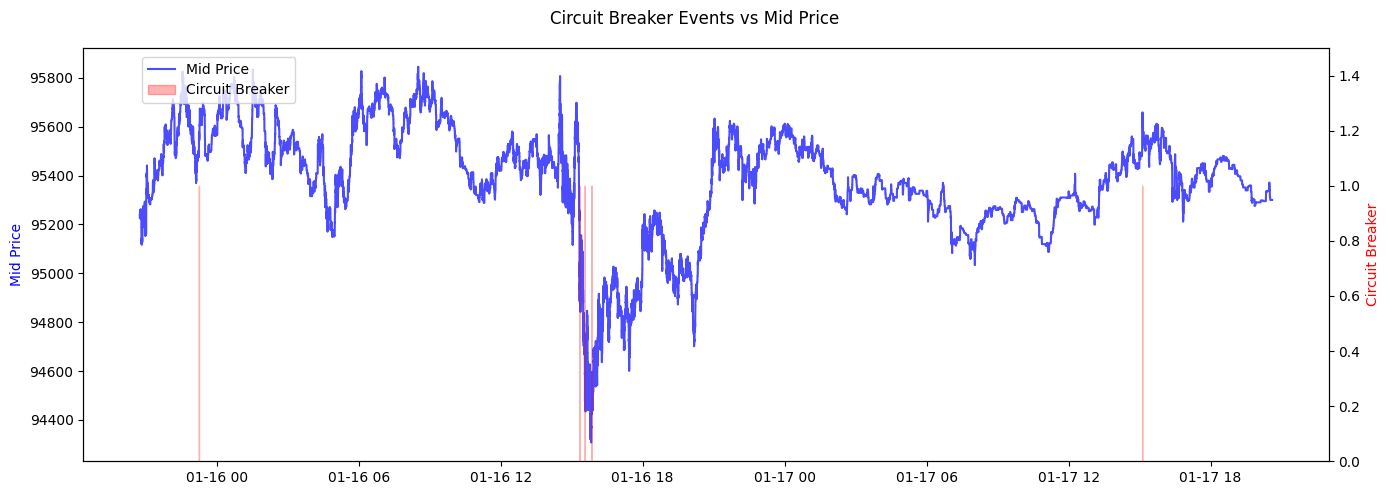

In [33]:
# Circuit breaker analysis
if basic_mm_signal.recorder is not None:
    df = basic_mm_signal.recorder.get_record(listing.listing_id).df

    cb_active = df['circuit_breaker_active'].astype(bool)
    total_ticks = len(df)
    cb_ticks = cb_active.sum()
    print(f"Circuit breaker fired: {cb_ticks}/{total_ticks} ticks ({cb_ticks/total_ticks*100:.2f}%)")

    # Plot circuit breaker timeline against mid price
    import matplotlib.pyplot as plt

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(df.index, df['mid_price'], color='blue', alpha=0.7, label='Mid Price')
    ax1.set_ylabel('Mid Price', color='blue')

    ax2 = ax1.twinx()
    ax2.fill_between(df.index, 0, cb_active.astype(int), alpha=0.3, color='red', label='Circuit Breaker')
    ax2.set_ylabel('Circuit Breaker', color='red')
    ax2.set_ylim(0, 1.5)

    fig.suptitle('Circuit Breaker Events vs Mid Price')
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()

,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,2657.437731,-2366.189372,0.006964,71.521016,0.734349,2.048738,-1.123088,24.810069,238.0


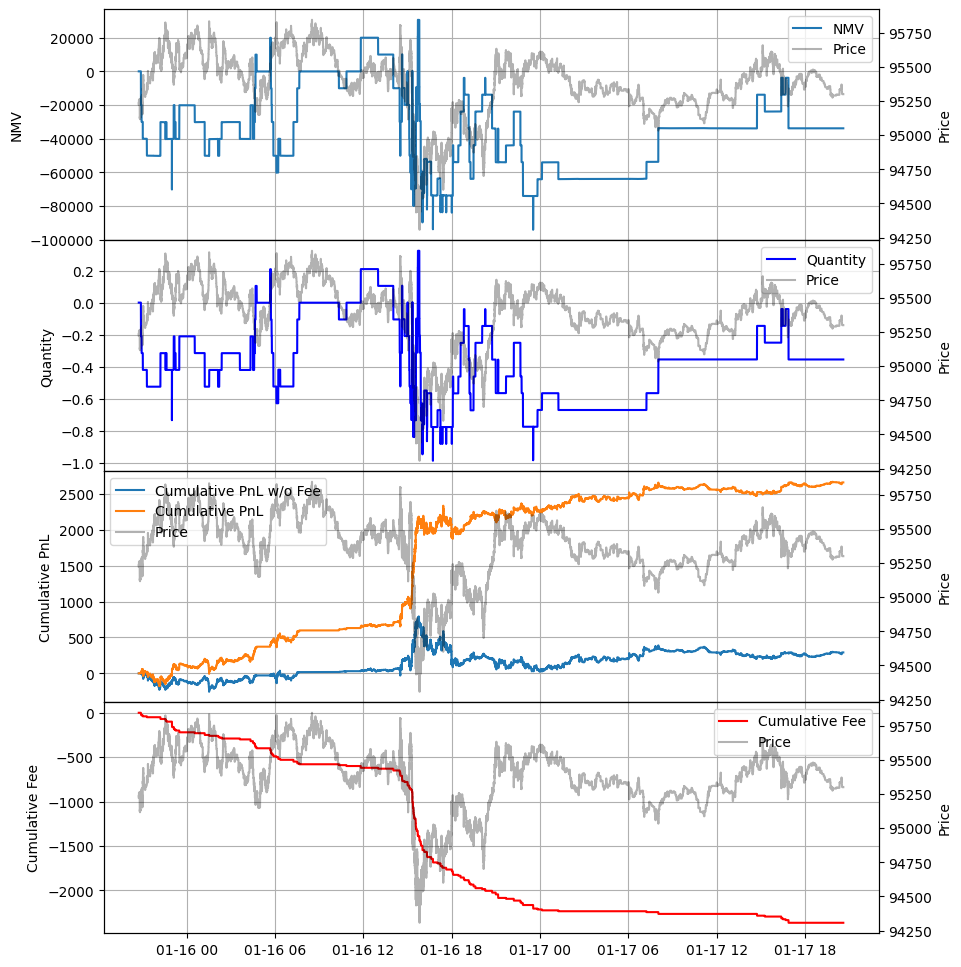

In [34]:
listing_stats = backtest.recorder.get_record(1).stats()
display(listing_stats.summary())
listing_stats.plot()

---
## LGBM Volatility Model Training

Train an LGBM regression model to predict forward absolute price movement in bps.
Uses the same 44 features as the directional model, but with regression objective
and absolute return labels.

### Training config

In [35]:
from gnomepy.research.signals.basic_mm.lgbm_volatility import LGBMVolatilityTrainer, LGBMVolatilityModel
from gnomepy.research.signals.lgbm_directional.registry import ModelRegistry
from gnomepy.research.signals.lgbm_directional.features import FEATURE_NAMES
import lightgbm as lgb

# Training date range (should precede or overlap backtest period)
TRAIN_START = datetime.datetime(2026, 1, 15, 12, 0)
TRAIN_END   = datetime.datetime(2026, 1, 18, 12, 0)

# Volatility model training parameters
VOL_HORIZON = 20          # ticks to look ahead for label
TRAIN_WINDOW = 50000      # rows per training fold
VAL_WINDOW   = 10000      # rows per validation fold

VOL_REGISTRY_DIR = "./vol_models"

### Load data & extract features

Loading data for listing 1 ...
  Loaded 861456 rows
  861237 usable samples
  Label stats: mean=0.38 bps, median=0.00 bps, std=1.89 bps

Features shape: (861237, 44)

Label distribution:


count    861237.000000
mean          0.377130
std           1.891201
min           0.000000
25%           0.000000
50%           0.000000
75%           0.210932
max         103.661630
dtype: float64

<Axes: >

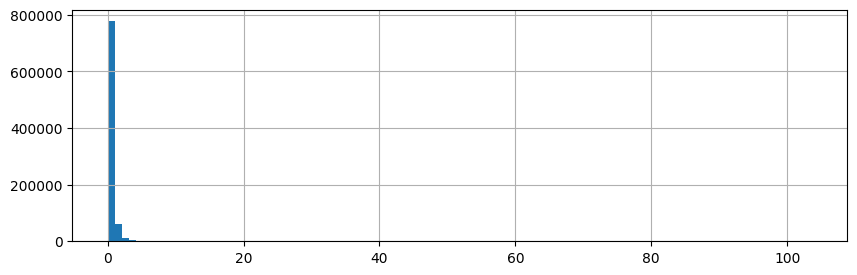

In [37]:
vol_trainer = LGBMVolatilityTrainer(
    listing_id=LISTING_IDS[0],
    start_datetime=TRAIN_START,
    end_datetime=TRAIN_END,
    schema_type=SCHEMA_TYPE,
    horizon=VOL_HORIZON,
    market_data_client=market_data_client,
    registry_client=registry_client,
)

X_vol, y_vol = vol_trainer.prepare()
print(f"\nFeatures shape: {X_vol.shape}")
print(f"\nLabel distribution:")
display(y_vol.describe())
y_vol.hist(bins=100, figsize=(10, 3))#, title="Label distribution (abs return in bps)")

### Walk-forward validation (default params)

  861237 usable samples
  Label stats: mean=0.38 bps, median=0.00 bps, std=1.89 bps

=== Walk-Forward Report ===

Fold 0: {'mae': 0.5271865921905731, 'rmse': 1.3706524671142297, 'median_ae': 0.29611068521787764, 'correlation': 0.06905295878183945}
Fold 1: {'mae': 0.40334764861859584, 'rmse': 0.951713479049748, 'median_ae': 0.2517417818828786, 'correlation': 0.11938243977196336}
Fold 2: {'mae': 0.46403290474950365, 'rmse': 1.0828248695370912, 'median_ae': 0.24955457174744214, 'correlation': 0.09990350828155073}
Fold 3: {'mae': 0.49480866458071115, 'rmse': 1.527933101978269, 'median_ae': 0.22758285124268812, 'correlation': 0.15579553995869516}
Fold 4: {'mae': 0.5120911802447318, 'rmse': 1.5671021407269505, 'median_ae': 0.29515287106428845, 'correlation': 0.02384241721512221}
Fold 5: {'mae': 0.4715289613303725, 'rmse': 1.9230486157333642, 'median_ae': 0.19714304291743887, 'correlation': 0.044231433852498565}
Fold 6: {'mae': 0.43009436365251524, 'rmse': 1.187145061573145, 'median_ae': 0.31

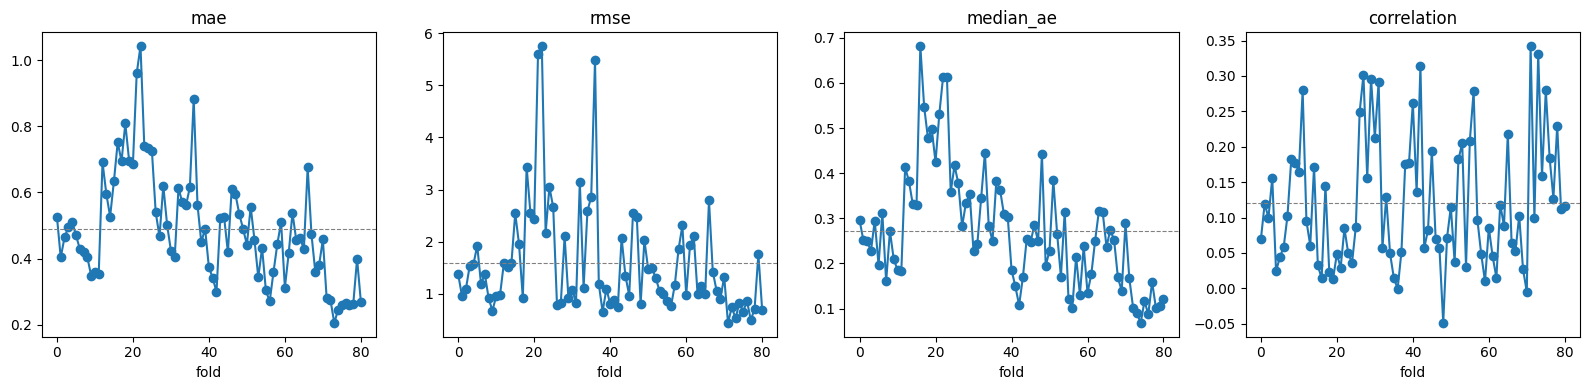

,mae,rmse,median_ae,correlation
fold,,,,
0,0.527187,1.370652,0.296111,0.069053
1,0.403348,0.951713,0.251742,0.119382
2,0.464033,1.082825,0.249555,0.099904
3,0.494809,1.527933,0.227583,0.155796
4,0.512091,1.567102,0.295153,0.023842
...,...,...,...,...
76,0.264686,0.866039,0.087440,0.184614
77,0.258343,0.494523,0.159487,0.126880
78,0.262947,0.709070,0.101770,0.229602


In [38]:
default_vol_params = {
    "num_leaves": 31,
    "max_depth": 6,
    "learning_rate": 0.05,
    "min_child_samples": 100,
    "feature_fraction": 0.8,
}

vol_fold_results = vol_trainer.walk_forward_validate(
    params=default_vol_params,
    train_window=TRAIN_WINDOW,
    val_window=VAL_WINDOW,
)

vol_report = vol_trainer.report(vol_fold_results)

# Plot per-fold metrics
import matplotlib.pyplot as plt

vol_metrics_df = pd.DataFrame([fr.metrics for fr in vol_fold_results])
vol_metrics_df.index.name = "fold"

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(["mae", "rmse", "median_ae", "correlation"]):
    vol_metrics_df[col].plot(ax=axes[i], marker="o", title=col)
    axes[i].axhline(vol_metrics_df[col].mean(), ls="--", color="grey", lw=0.8)
plt.tight_layout()
plt.show()
display(vol_metrics_df)

### Hyperparameter tuning (optional)

Uncomment to run random search. Otherwise uses `default_vol_params`.

In [ ]:
# from gnomepy.research.signals.basic_mm.lgbm_volatility.trainer import DEFAULT_PARAM_GRID
#
# vol_tuning_result = vol_trainer.tune_hyperparameters(
#     param_grid=DEFAULT_PARAM_GRID,
#     train_window=TRAIN_WINDOW,
#     val_window=VAL_WINDOW,
#     n_random=20,
#     metric="mae",
# )
#
# print(f"\nBest params: {vol_tuning_result.best_params}")
# display(pd.DataFrame(vol_tuning_result.all_results).head(10))

### Train final model & register

In [39]:
vol_registry = ModelRegistry(base_dir=VOL_REGISTRY_DIR)

# Use default_vol_params, or vol_tuning_result.best_params if tuning was run
vol_model_lgbm = vol_trainer.train(
    params=default_vol_params,
    register=True,
    registry=vol_registry,
)

print(f"\nRegistered versions:")
display(vol_registry.compare(LISTING_IDS[0]))

  861237 usable samples
  Label stats: mean=0.38 bps, median=0.00 bps, std=1.89 bps
  861237 usable samples
  Label stats: mean=0.38 bps, median=0.00 bps, std=1.89 bps
Registered as v1

Registered versions:


,created_at,mean_auc,mean_accuracy
version,,,
v1,2026-02-22T00:51:17.340962+00:00,None,None


### Feature importance

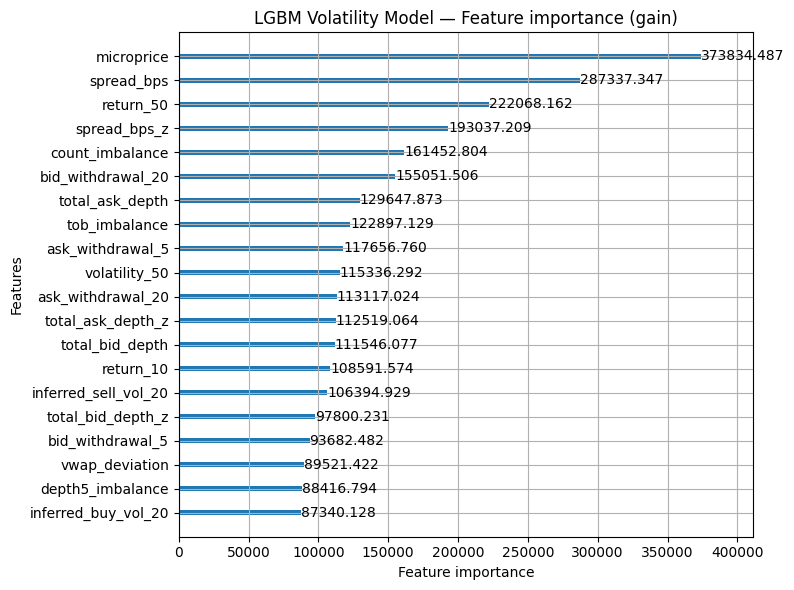

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
lgb.plot_importance(vol_model_lgbm, ax=ax, importance_type="gain", max_num_features=20)
ax.set_title("LGBM Volatility Model — Feature importance (gain)")
plt.tight_layout()
plt.show()

---
## Backtest with LGBM Volatility Model

Re-run the backtest using the trained `LGBMVolatilityModel` instead of
`RealizedVolatilityModel`. The LGBM model's prediction feeds both the
circuit breaker and the AS sigma parameter.

In [41]:
# Load LGBM volatility model from registry
lgbm_vol_model = LGBMVolatilityModel(
    registry=vol_registry,
    listing_id=LISTING_IDS[0],
    horizon=VOL_HORIZON,
)
print(f"LGBM vol model: min_lookback={lgbm_vol_model.min_lookback}, horizon={lgbm_vol_model.horizon}")

# Create new exchange instances (fresh state)
lgbm_exchanges = {
    listing.exchange_id: {
        listing.security_id: MBPSimulatedExchange(
            fee_model=StaticFeeModel(taker_fee=0.004, maker_fee=-0.001),
            network_latency=NETWORK_LATENCY,
            order_processing_latency=ORDER_PROCESSING_LATENCY,
            queue_model=RiskAverseQueueModel()
        )
    }
}

lgbm_signal_recorder = BasicMMRecorder(listing_ids=LISTING_IDS)

lgbm_mm_signal = BasicMMSignal(
    listing=listing,
    volatility_model=lgbm_vol_model,
    data_schema_type=SCHEMA_TYPE,
    **BASIC_MM_PARAMS,
    recorder=lgbm_signal_recorder,
)

lgbm_oms = LimitOrderOMS(
    signals=[lgbm_mm_signal],
    notional=NOTIONAL,
    position_aware_sizing=False,
    position_scaling_factor=0.3,
)

lgbm_strategy = OMSStrategy(processing_latency=STRATEGY_LATENCY, oms=lgbm_oms)
print("LGBM backtest components created.")

LGBM vol model: min_lookback=201, horizon=20
LGBM backtest components created.


In [42]:
lgbm_backtest = Backtest(
    start_datetime=START_DATETIME,
    end_datetime=END_DATETIME,
    listing_ids=LISTING_IDS,
    schema_type=SCHEMA_TYPE,
    strategy=lgbm_strategy,
    exchanges=lgbm_exchanges,
    market_data_client=market_data_client,
    registry_client=registry_client,
)

print("Preparing data...")
lgbm_backtest.prepare_data()

print("Executing LGBM backtest...")
lgbm_backtest.fully_execute()
print("Done.")

Preparing data...
Executing LGBM backtest...
Done.


### LGBM backtest results

Signal positions: {<gnomepy.research.signals.basic_mm.signal.BasicMMSignal object at 0x32c89c2b0>: {1: -0.7719777954739901}}
Overall positions: {1: -0.7719777954739901}


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,10626.733634,-12040.177781,0.016753,162.493122,1.218273,2.295133,-0.882606,0.0,0.0


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades,listing_id
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,10626.733634,-12040.177781,0.016753,162.493122,1.218273,2.295133,-0.882606,124.850009,1268.0,1


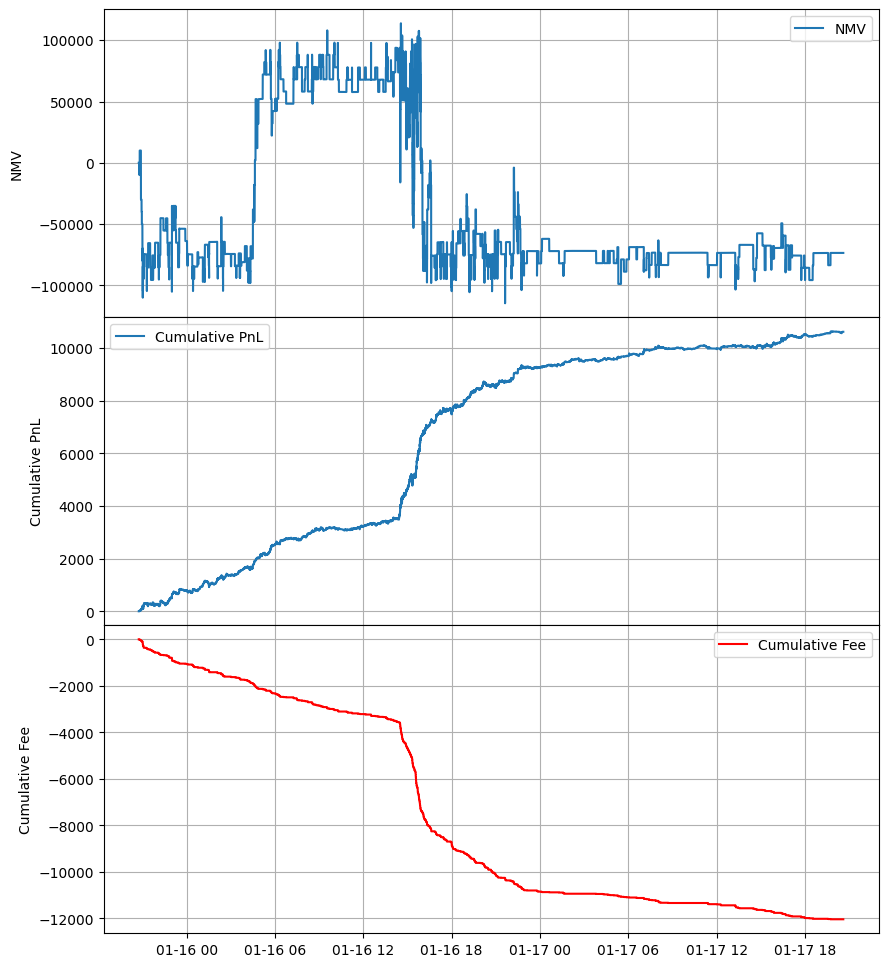

In [47]:
print(f"Signal positions: {lgbm_oms.signal_positions}")
print(f"Overall positions: {lgbm_oms.positions}")

lgbm_strat_sts = StrategyStats(
    {
        listing_id: lgbm_backtest.recorder.get_record(listing_id).stats()
        for listing_id in LISTING_IDS
    },
)

display(lgbm_strat_sts.summary())
display(lgbm_strat_sts.listing_summary())
lgbm_strat_sts.plot()

,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,10626.733634,-12040.177781,0.016753,162.493122,1.218273,2.295133,-0.882606,124.850009,1268.0


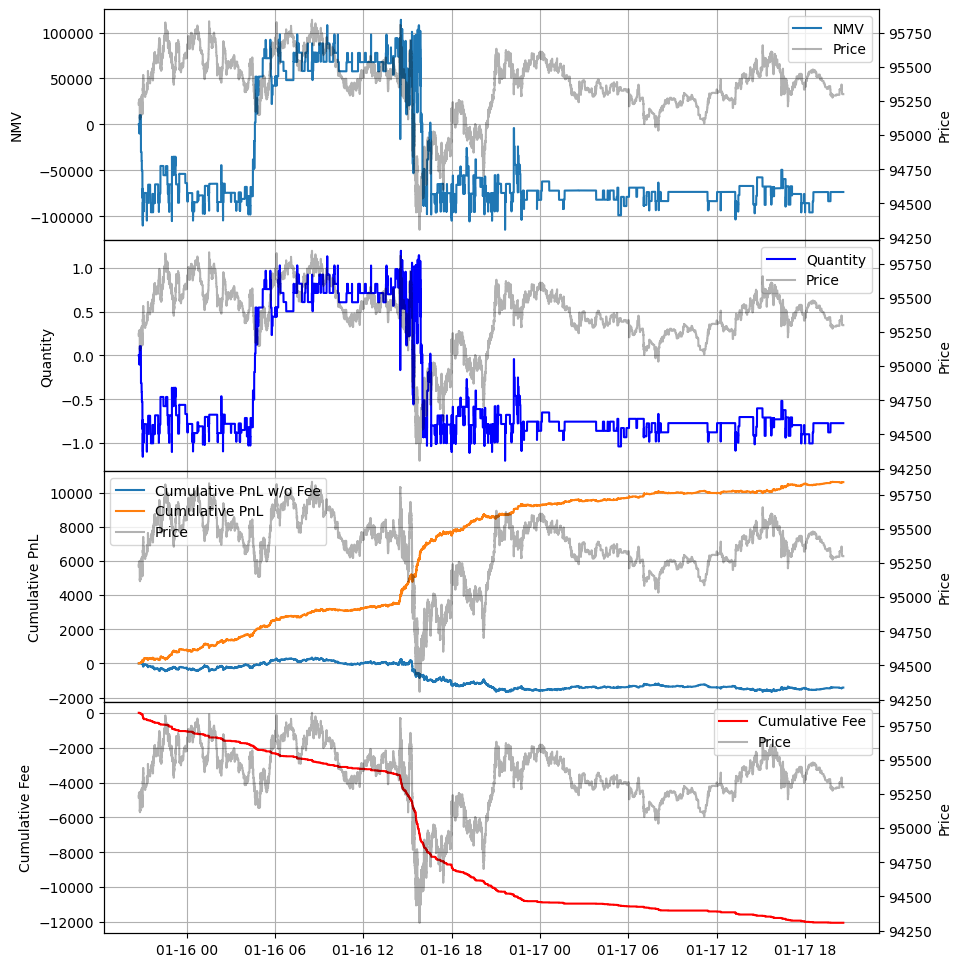

In [48]:
lgbm_listing_stats = lgbm_backtest.recorder.get_record(1).stats()
display(lgbm_listing_stats.summary())
lgbm_listing_stats.plot()

### LGBM model values & circuit breaker

,mid_price,inventory,realized_vol,predicted_vol_bps,optimal_bid,optimal_ask,reservation_price,best_bid,best_ask,bid_confidence,ask_confidence,circuit_breaker_active,spread
timestamp,,,,,,,,,,,,,
2026-01-15 20:45:28.780828502,95239.5,0.0,0.00001,0.379957,95238.805556,95240.194444,95239.5,95239.0,95240.0,0.1,0.1,0,1.0
2026-01-15 20:45:29.191885857,95239.5,0.0,0.00001,0.315760,95238.805556,95240.194444,95239.5,95239.0,95240.0,0.1,0.1,0,1.0
2026-01-15 20:45:29.780758332,95239.5,0.0,0.00001,0.240222,95238.805556,95240.194444,95239.5,95239.0,95240.0,0.1,0.1,0,1.0
2026-01-15 20:45:30.382248231,95239.5,0.0,0.00001,0.265820,95238.805556,95240.194444,95239.5,95239.0,95240.0,0.1,0.1,0,1.0
2026-01-15 20:45:30.780766187,95239.5,0.0,0.00001,0.248785,95238.805556,95240.194444,95239.5,95239.0,95240.0,0.1,0.1,0,1.0
2026-01-15 20:45:31.280735874,95239.5,0.0,0.00001,0.248785,95238.805556,95240.194444,95239.5,95239.0,95240.0,0.1,0.1,0,1.0
2026-01-15 20:45:31.382145743,95239.5,0.0,0.00001,0.210121,95238.805556,95240.194444,95239.5,95239.0,95240.0,0.1,0.1,0,1.0
2026-01-15 20:45:31.880748985,95239.5,0.0,0.00001,0.182444,95238.805556,95240.194444,95239.5,95239.0,95240.0,0.1,0.1,0,1.0
2026-01-15 20:45:32.280748658,95239.5,0.0,0.00001,0.182444,95238.805556,95240.194444,95239.5,95239.0,95240.0,0.1,0.1,0,1.0


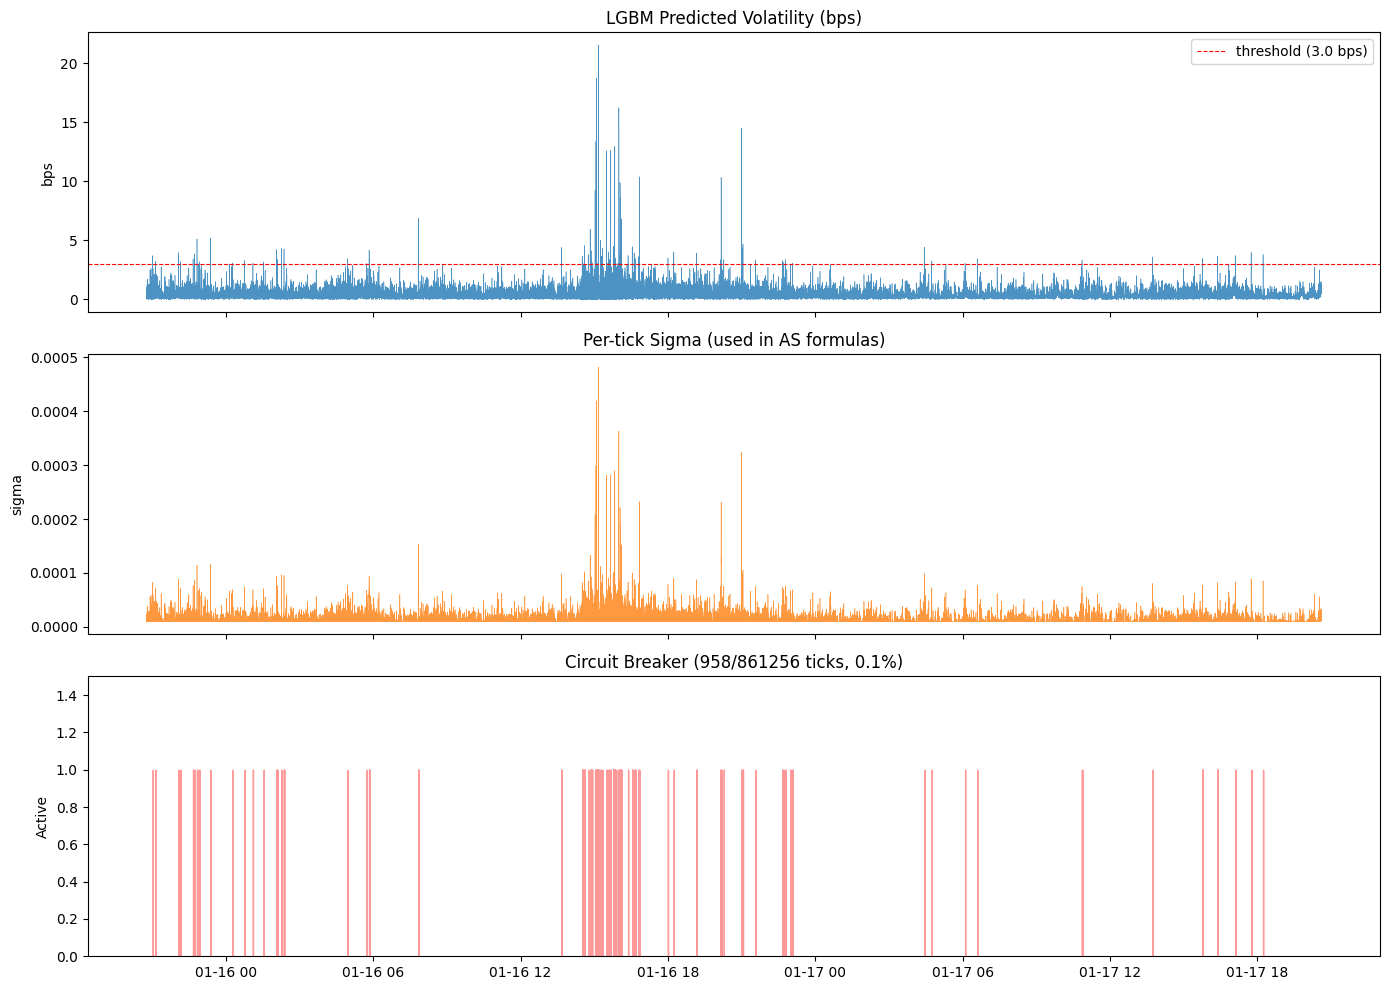

In [44]:
if lgbm_mm_signal.recorder is not None:
    lgbm_df = lgbm_mm_signal.recorder.get_record(listing.listing_id).df
    display(lgbm_df.head(20))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Predicted vol over time
    axes[0].plot(lgbm_df.index, lgbm_df['predicted_vol_bps'], linewidth=0.4, alpha=0.8)
    axes[0].axhline(BASIC_MM_PARAMS['vol_threshold_bps'], color='red', ls='--', lw=0.8,
                     label=f"threshold ({BASIC_MM_PARAMS['vol_threshold_bps']} bps)")
    axes[0].set_ylabel('bps')
    axes[0].set_title('LGBM Predicted Volatility (bps)')
    axes[0].legend()

    # Realized vol (per-tick sigma derived from model)
    axes[1].plot(lgbm_df.index, lgbm_df['realized_vol'], linewidth=0.4, alpha=0.8, color='tab:orange')
    axes[1].set_ylabel('sigma')
    axes[1].set_title('Per-tick Sigma (used in AS formulas)')

    # Circuit breaker timeline
    cb = lgbm_df['circuit_breaker_active'].astype(bool)
    cb_pct = cb.sum() / len(lgbm_df) * 100
    axes[2].fill_between(lgbm_df.index, 0, cb.astype(int), alpha=0.4, color='red')
    axes[2].set_ylabel('Active')
    axes[2].set_title(f'Circuit Breaker ({cb.sum()}/{len(lgbm_df)} ticks, {cb_pct:.1f}%)')
    axes[2].set_ylim(0, 1.5)

    plt.tight_layout()
    plt.show()

### RealizedVol vs LGBM comparison

,RealizedVol,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,...,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,2657.437731,-2366.189372,0.006964,71.521016,0.734349,2.048738,-1.123088,24.810069,...,2026-01-17 20:35:59.891429776,10626.733634,-12040.177781,0.016753,162.493122,1.218273,2.295133,-0.882606,124.850009,1268.0



Circuit breaker comparison:
  RealizedVol: 451/861356 ticks (0.1%)
  LGBM:        958/861256 ticks (0.1%)


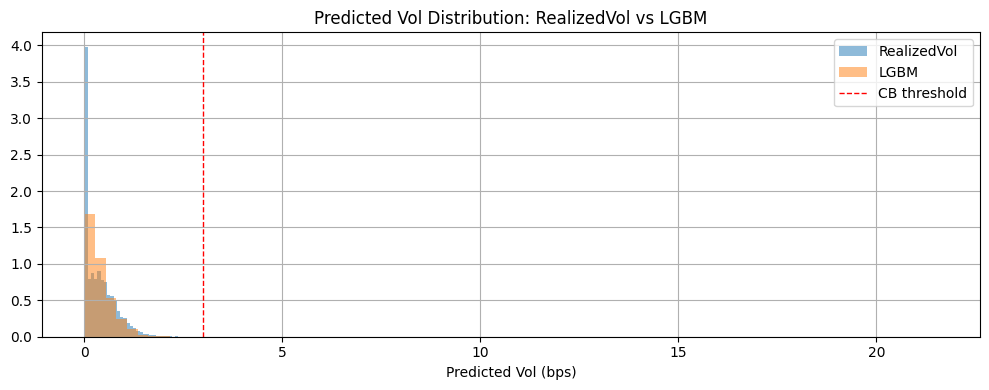

In [45]:
# Compare the two backtests side-by-side
realized_stats = backtest.recorder.get_record(LISTING_IDS[0]).stats()
lgbm_stats = lgbm_backtest.recorder.get_record(LISTING_IDS[0]).stats()

comparison = pd.concat([
    realized_stats.summary().rename(columns={realized_stats.summary().columns[0]: "RealizedVol"}),
    lgbm_stats.summary().rename(columns={lgbm_stats.summary().columns[0]: "LGBM"}),
], axis=1)
display(comparison)

# Compare recorder stats
rv_rec_df = basic_mm_signal.recorder.get_record(listing.listing_id).df
lgbm_rec_df = lgbm_mm_signal.recorder.get_record(listing.listing_id).df

rv_cb = rv_rec_df['circuit_breaker_active'].astype(bool)
lgbm_cb = lgbm_rec_df['circuit_breaker_active'].astype(bool)

print(f"\nCircuit breaker comparison:")
print(f"  RealizedVol: {rv_cb.sum()}/{len(rv_rec_df)} ticks ({rv_cb.mean()*100:.1f}%)")
print(f"  LGBM:        {lgbm_cb.sum()}/{len(lgbm_rec_df)} ticks ({lgbm_cb.mean()*100:.1f}%)")

# Overlay predicted vol distributions
fig, ax = plt.subplots(figsize=(10, 4))
rv_rec_df['predicted_vol_bps'].dropna().hist(ax=ax, bins=80, alpha=0.5, label='RealizedVol', density=True)
lgbm_rec_df['predicted_vol_bps'].dropna().hist(ax=ax, bins=80, alpha=0.5, label='LGBM', density=True)
ax.axvline(BASIC_MM_PARAMS['vol_threshold_bps'], color='red', ls='--', lw=1, label='CB threshold')
ax.set_xlabel('Predicted Vol (bps)')
ax.set_title('Predicted Vol Distribution: RealizedVol vs LGBM')
ax.legend()
plt.tight_layout()
plt.show()